# Clasificación: Árboles de Decisión y Reglas Lógicas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/04_clasificacion_arboles_y_reglas.ipynb)


## Objetivos


- Introducir el paradigma de partición lógica del espacio mediante reglas *If-Else* ortogonales.
- Comprender la importancia de la **interpretabilidad** de los modelos en contextos médicos, legales o financieros.
- Extraer y visualizar la importancia nativa de las características (*Feature Importance*).
- Identificar el principal defecto de los árboles: su altísima varianza (tendencia al sobreajuste).



## Prerrequisitos


- Entendimiento del *Trade-off* Sesgo-Varianza.
- Haber completado: [Introducción a la Clasificación y Fronteras de Decisión](01_introduccion_clasificacion.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()


## Introducción Teórica



Hasta ahora, vimos modelos que operan como "cajas negras" matemáticas. Un SVM o una Regresión Logística multiplican los datos por una serie de pesos ($w$) y los pasan por funciones continuas. Si le decimos a un médico: *"El paciente tiene un 85% de probabilidad de sufrir un ACV porque el producto punto de su vector de características con el hiperplano de margen máximo es 2.4"*, el médico, con justa razón, rechazará tu modelo.

En sectores críticos (salud, finanzas, legal), **la interpretabilidad es un requisito no negociable**. Necesitamos saber *por qué* el modelo toma una decisión.



### El Enfoque Lógico: Jugando a "Adivina Quién"



Los **Árboles de Decisión** abandonan las matemáticas continuas y adoptan la lógica discreta. Funcionan exactamente igual que el juego de mesa "Adivina Quién" (*Guess Who?*).

El algoritmo busca la pregunta (regla *If-Else*) que mejor divida a los datos en dos grupos lo más "puros" posibles. Por ejemplo: *"¿La edad es mayor a 60?"*.
- Si la respuesta es Sí, los envía a la rama derecha.
- Si es No, a la rama izquierda.
Luego, se repite el proceso en cada rama hasta llegar a una conclusión (la hoja del árbol).


Por supuesto... **hay muchas maneras de hacer las preguntas**, unas pueden ser "más inteligentes" que otras, el orden puede importar, etc.


### Impureza de Gini y Entropía



¿Cómo sabe el algoritmo qué pregunta hacer primero? Evalúa todas las variables y todos los puntos de corte posibles, calculando una métrica de "impureza" (usualmente el Índice de Gini o la Entropía).

El **Índice de Gini** mide la probabilidad de clasificar incorrectamente un elemento elegido al azar si lo etiquetáramos aleatoriamente según la distribución de clases del nodo. Un nodo "puro" (donde todos los pacientes tuvieron un ACV, o ninguno lo tuvo) tiene un Gini de 0. El algoritmo siempre elegirá el corte que minimice el Gini promedio de los nodos resultantes.

Ver imagen de ejemplo, para la distribución de estos datos, es evidente que hay 2 preguntas clave para aislar totalmente a los puntos rojos (pacientes enfermos):


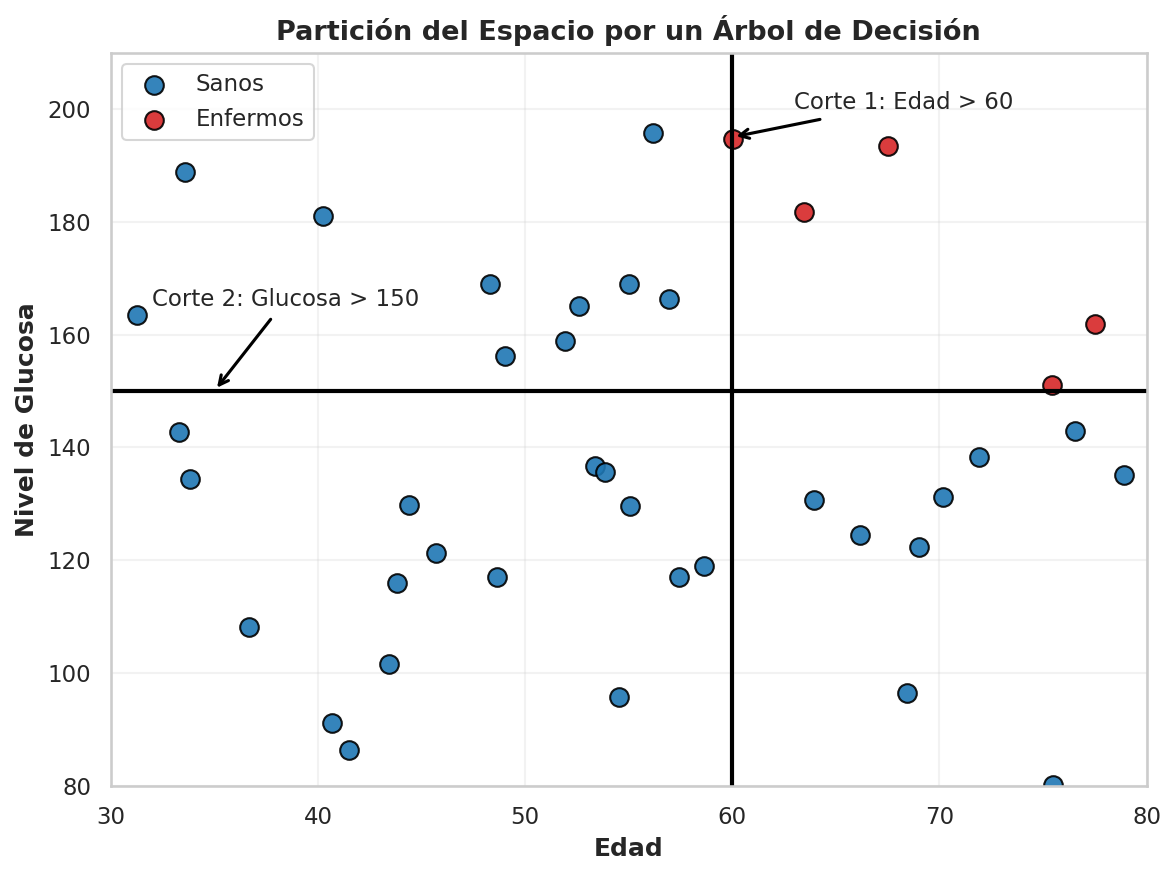

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Generar datos sintéticos
# -------------------------
np.random.seed(7)

n = 40

edad = np.random.uniform(30, 80, n)
glucosa = np.random.uniform(80, 200, n)

# Regla artificial para clases, inventado para ilustrar (desconozco qué pasa en la realidad...)
enfermo = (edad > 60) & (glucosa > 150)

X_sano = np.column_stack((edad[~enfermo], glucosa[~enfermo]))
X_enfermo = np.column_stack((edad[enfermo], glucosa[enfermo]))

# -------------------------
# Crear figura
# -------------------------
plt.figure(figsize=(8,6))

# Puntos
plt.scatter(X_sano[:,0], X_sano[:,1],
            color="#1f77b4",
            edgecolor="black",
            s=80,
            label="Sanos",
            alpha=0.9)

plt.scatter(X_enfermo[:,0], X_enfermo[:,1],
            color="#d62728",
            edgecolor="black",
            s=80,
            label="Enfermos",
            alpha=0.9)

# -------------------------
# Cortes del árbol
# -------------------------
corte_edad = 60
corte_glucosa = 150

# Línea vertical (primer split)
plt.axvline(corte_edad,
            color="black",
            linewidth=2)

# Línea horizontal (segundo split)
plt.axhline(corte_glucosa,
            color="black",
            linewidth=2)

# -------------------------
# Anotaciones
# -------------------------

plt.annotate("Corte 1: Edad > 60",
             xy=(corte_edad, 195),
             xytext=(63, 200),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="black"),
             fontsize=11)

plt.annotate("Corte 2: Glucosa > 150",
             xy=(35, corte_glucosa),
             xytext=(32, 165),
             arrowprops=dict(arrowstyle="->", lw=1.5, color="black"),
             fontsize=11)


plt.xlabel("Edad", fontsize=12)
plt.ylabel("Nivel de Glucosa", fontsize=12)
plt.title("Partición del Espacio por un Árbol de Decisión", fontsize=13)

plt.grid(alpha=0.25)
plt.xlim(30,80)
plt.ylim(80,210)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## Desarrollo e Implementación



Vamos a utilizar el **Stroke Prediction Dataset (ACV)**. Nuestro objetivo es predecir si un paciente sufrirá un accidente cerebrovascular (`apoplejia` = 1) basándonos en su historial clínico.

Para mantener el enfoque estrictamente en el algoritmo, realizamos una limpieza rápida eliminando los valores nulos. (En el mundo real, y como veremos en el notebook de *Pipelines*, imputaríamos estos valores).



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. Carga de datos
dataset_path = "datasets/acv/datos_acv.csv"
df = load_dataset(dataset_path)

# 2. Limpieza rápida (Solo para fines didácticos en este notebook)
# Eliminamos el ID (no tiene poder predictivo) y las filas con nulos (IMC)
df = df.drop(columns=['id']).dropna()

# Convertimos variables categóricas a numéricas (One-Hot Encoding rápido)
# Scikit-Learn requiere que todas las entradas sean numéricas
df_encoded = pd.get_dummies(df, drop_first=True)

# Separamos Features (X) y Target (y)
X = df_encoded.drop(columns=['apoplejia'])
y = df_encoded['apoplejia']

# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Variables predictoras ({X.shape[1]}): {list(X.columns)}")


Dataset cargado exitosamente con 5110 filas y 12 columnas.
Variables predictoras (16): ['edad', 'hipertension', 'enfermedad_corazon', 'casado_alguna_vez', 'nivel_glucosa', 'imc', 'genero_mujer', 'genero_otro', 'tipo_trabajo_con_niños', 'tipo_trabajo_gubernamental', 'tipo_trabajo_nunca_trabajo', 'tipo_trabajo_privado', 'tipo_residencia_urbano', 'estado_fumador_fuma', 'estado_fumador_fumaba', 'estado_fumador_nunca']


### Entrenando un Árbol Interpretable



Si dejamos que el árbol crezca sin límites, creará miles de reglas hasta memorizar cada paciente, volviéndose incomprensible y sufriendo de sobreajuste (*Overfitting*).

Para garantizar la interpretabilidad, vamos a "podar" el árbol limitando su profundidad máxima a 3 niveles (`max_depth=3`). Este es uno de los hiperparámetros que podemos ajustar, recomiendo leer la documentación siempre para profundizar, entender y experimentar con los demás.


In [19]:
# Instanciamos y entrenamos el modelo limitando su profundidad
arbol_interpretable = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
arbol_interpretable.fit(X_train, y_train)

# Evaluamos rápidamente
y_pred = arbol_interpretable.predict(X_test)
print("Reporte de Clasificación (Profundidad = 3):")
print(classification_report(y_test, y_pred))


Reporte de Clasificación (Profundidad = 3):
              precision    recall  f1-score   support

           0       0.98      0.73      0.84       940
           1       0.10      0.69      0.18        42

    accuracy                           0.73       982
   macro avg       0.54      0.71      0.51       982
weighted avg       0.94      0.73      0.81       982




*Nota de Ingeniería:* Usamos `class_weight='balanced'`. Los ACV son eventos raros (clase minoritaria). Si no le decimos al árbol que preste especial atención a esta clase, simplemente predeciría "Sano" para todos y obtendría un `96%` de *Accuracy*, lo cual es inútil en medicina.



In [12]:
from utils.plots import render_classification_report

# En el repositorio hay funciones para renderizar en formato tabla el reporte de clasificación
render_classification_report(y_test, y_pred, classes=["No sufrirá ACV", "SUFRIRÁ ACV"])

,precision,recall,f1-score,support
No sufrirá ACV,0.9815,0.7319,0.8385,940
SUFRIRÁ ACV,0.1032,0.6905,0.1796,42
accuracy,0.7301,0.7301,0.7301,1
macro avg,0.5423,0.7112,0.5090,982
weighted avg,0.9439,0.7301,0.8103,982


Simplemente para verificar lo mencionado, analizar los resultados obtenidos con la siguiente configuración:

In [13]:
# MISMO MODELO, MISMOS DATOS... pero ahora el class_weight=None por defecto
arbol_interpretable_inutil = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_interpretable_inutil.fit(X_train, y_train)

# Notar los warnings... dan información clave sobre lo que está pasando
y_pred_inutil = arbol_interpretable_inutil.predict(X_test)
print("Reporte de Clasificación (Profundidad = 3):")
print(classification_report(y_test, y_pred_inutil))

Reporte de Clasificación (Profundidad = 3):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       940
           1       0.00      0.00      0.00        42

    accuracy                           0.96       982
   macro avg       0.48      0.50      0.49       982
weighted avg       0.92      0.96      0.94       982



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Ahora apareció el modelo con el `96%` de *Accuracy*. ¿Cómo lo sabía de antemano?
El EDA es clave siempre, en este caso... la proporción entre clases es justamente ese valor.

Pero:

- ¿Sirven estos modelos?
- ¿Qué nos dicen las métricas?

Probar con una matriz de confusión (*ya está importada la de scikit-learn*), quizá permita visualizar mejor el panorama...

Independiente de si gustan o no los resultados (se puede hacer mucho), estos modelos permiten analizar "la lógica de decisión".

### Visualizando la Lógica de Decisión



Aquí radica el verdadero poder de los árboles. Podemos exportar su "cerebro" a un diagrama de flujo que cualquier profesional de la salud puede leer y validar (refutar o lo que corresponda).



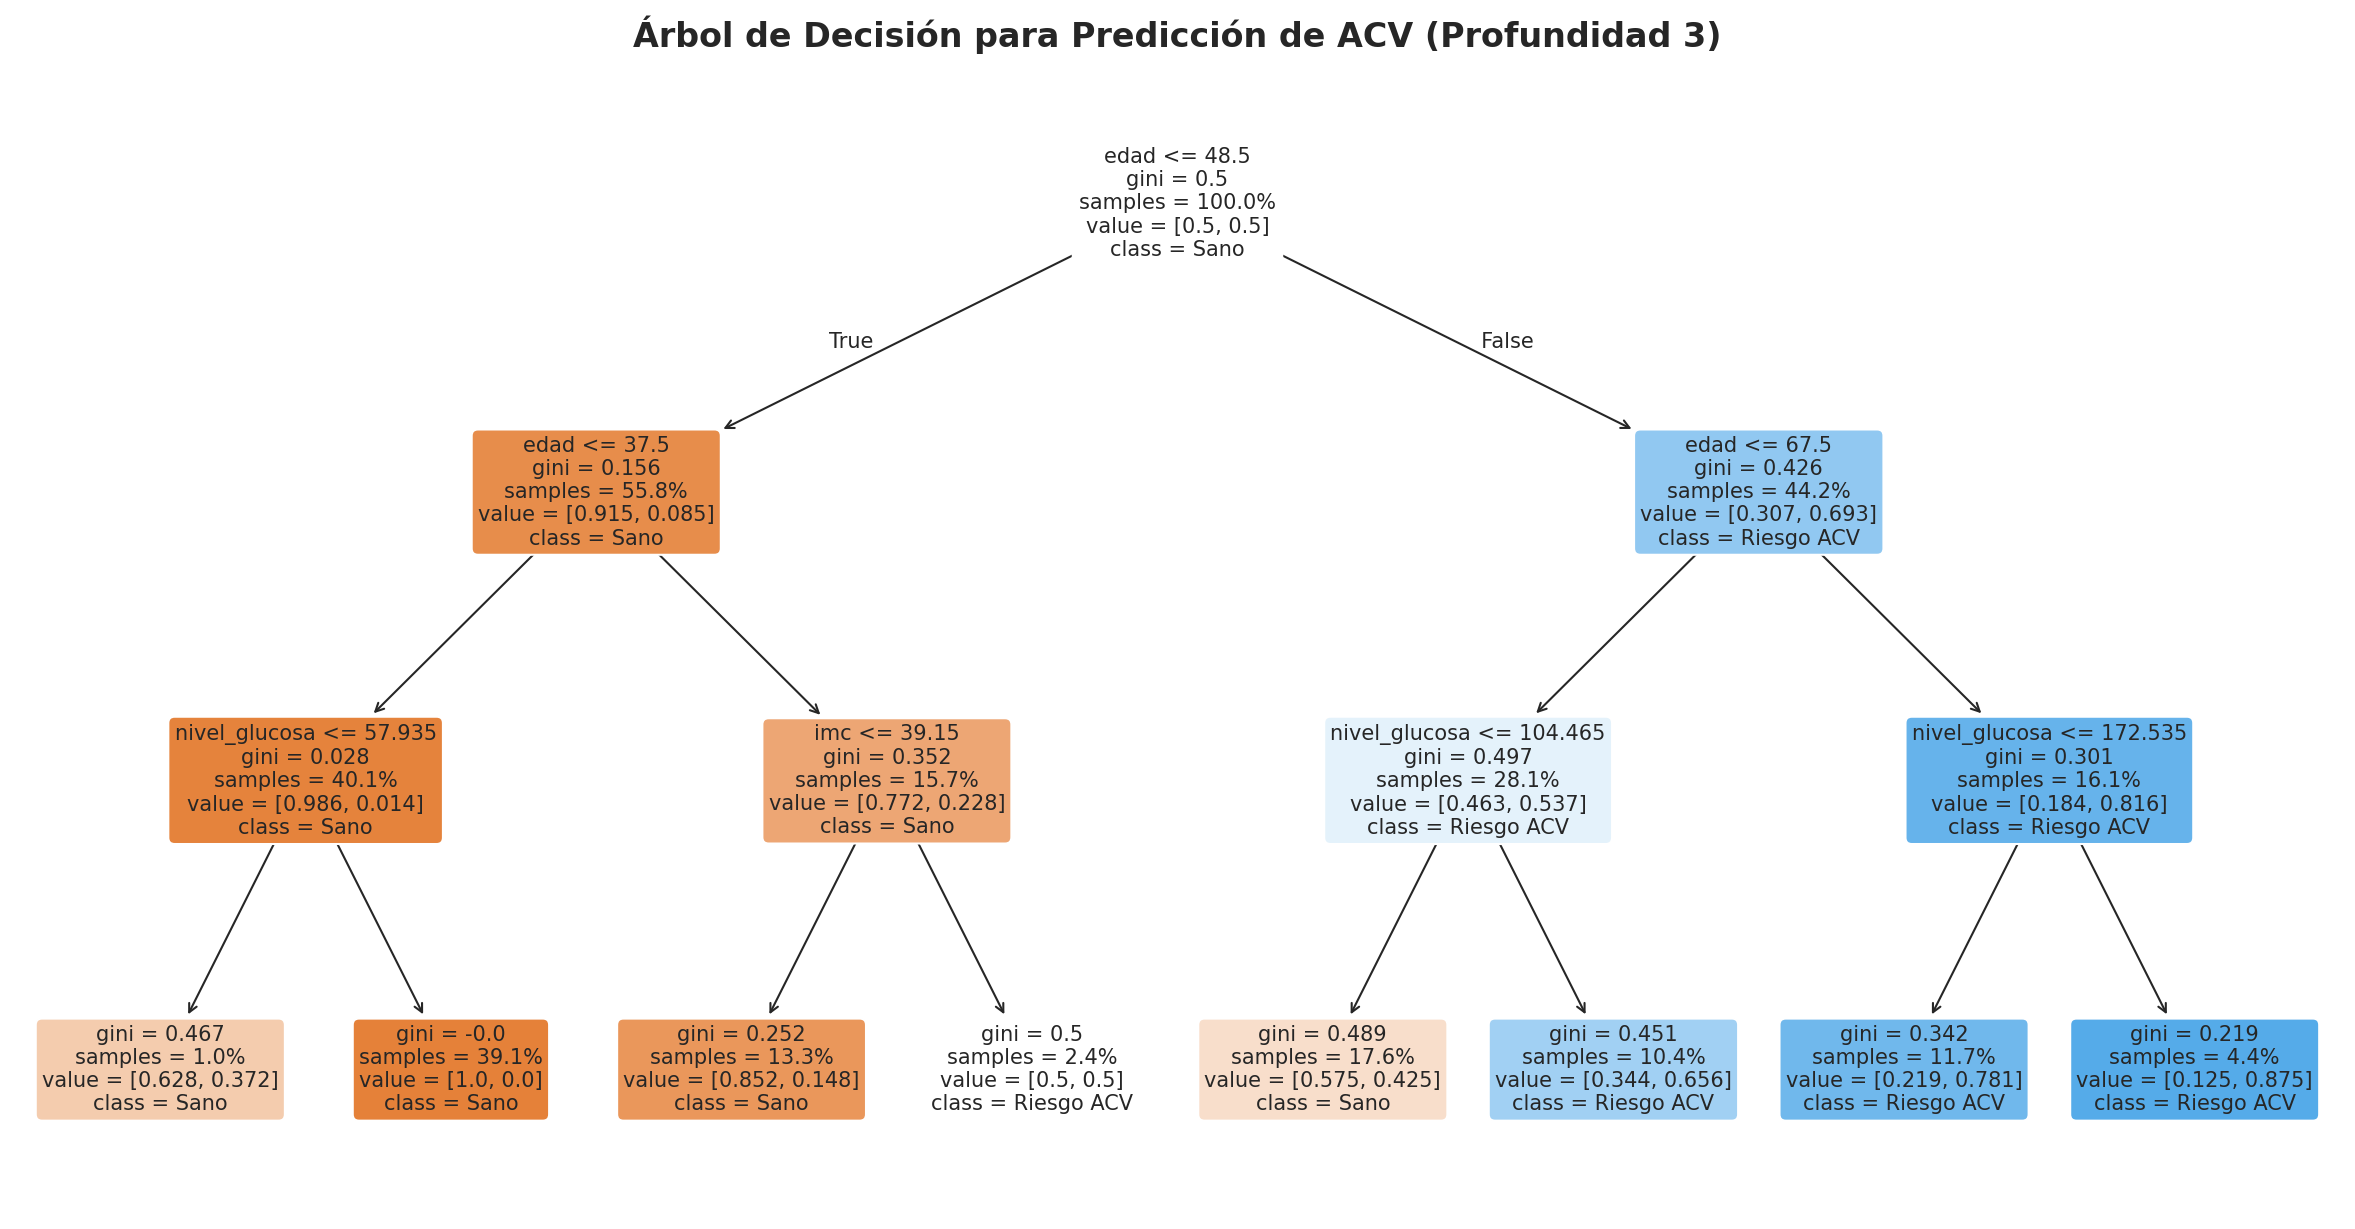

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(arbol_interpretable,
          feature_names=X.columns,
          class_names=['Sano', 'Riesgo ACV'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title("Árbol de Decisión para Predicción de ACV (Profundidad 3)", fontsize=16)
plt.show()


## Resultados y Discusión



Analicemos el gráfico superior con criterio clínico y de ingeniería:

1. **El Nodo Raíz (La pregunta más importante):** El árbol decidió que la variable más crítica para separar a los pacientes sanos de los que sufren un ACV es la **Edad**. Si la edad es menor a un cierto umbral (`48.5` años en este caso), el paciente va hacia la izquierda (zona naranja/segura). Si es mayor, va a la derecha (zona azul/riesgo).
2. **Reglas Compuestas:** Seguir una rama hacia la derecha. Se puede apreciar que el modelo combina reglas: *"Si Edad > `48.5` Y Edad < `67.5` Y Nivel de Glucosa > `104.5` Y ..."*. Esto es exactamente como razona un médico.
3. **Colores y Pureza:** Los nodos más naranjas indican una alta concentración de pacientes sanos. Los nodos más azules indican una alta concentración de pacientes con ACV. El valor `gini` muestra qué "tan mezclado" está ese nodo (que tan "contaminado" o cuánto permite separar la pregunta dada).



### *Feature Importance* (Importancia de Características)



Otra ventaja masiva de los árboles es que nos dicen matemáticamente qué variables son inútiles y cuáles son vitales, basándose en cuánta "impureza" lograron reducir durante el entrenamiento.



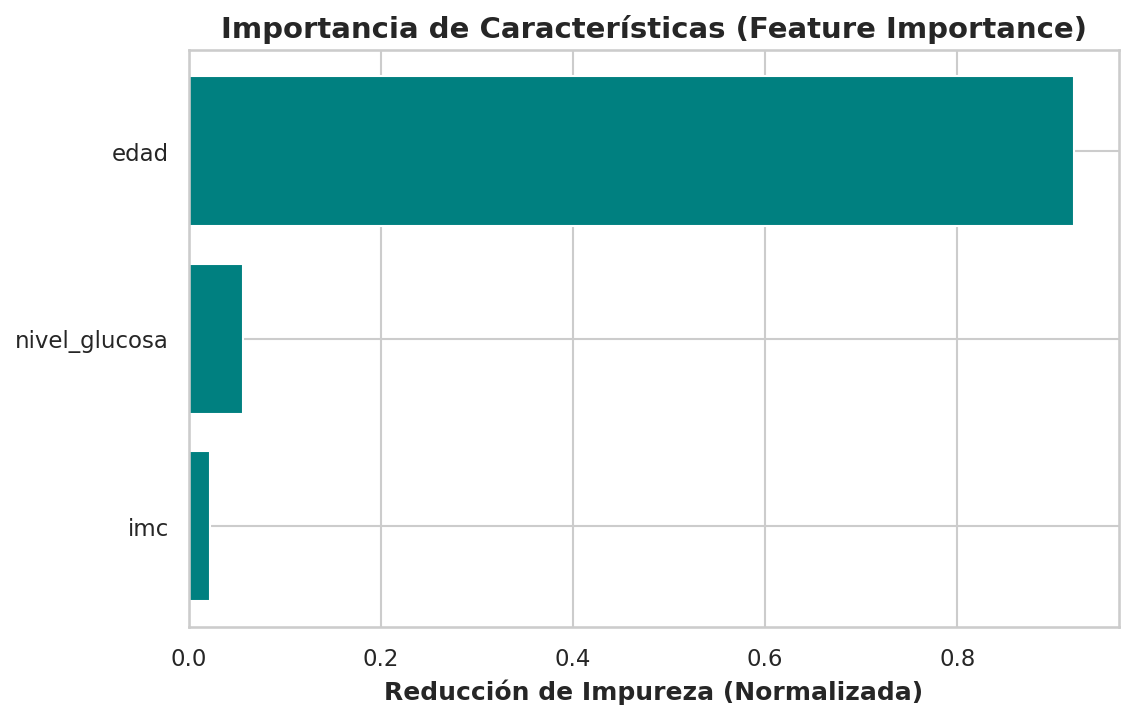

In [21]:
# Extraemos la importancia de las características
importancias = arbol_interpretable.feature_importances_

# Creamos un DataFrame para visualizarlo mejor
df_importancias = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Filtramos solo las que tienen importancia > 0
df_importancias = df_importancias[df_importancias['Importancia'] > 0]

plt.figure(figsize=(8, 5))
plt.barh(df_importancias['Característica'][::-1], df_importancias['Importancia'][::-1], color='teal')
plt.title("Importancia de Características (Feature Importance)")
plt.xlabel("Reducción de Impureza (Normalizada)")
plt.show()



Este gráfico es oro puro para el negocio. Nos dice que, de las decenas de variables que recolectamos, la Edad, el Nivel de Glucosa y el IMC son las que realmente importan para este modelo específico. Las demás (como el tipo de residencia) fueron ignoradas por el árbol en sus primeros 3 niveles.

**NOTA**: ¿Justo `3 features` "importantes"? ¿No coincide este valor con uno de los hiperparámetros que fijamos? Explorar qué pasa al modificarlo... ¿Podríamos utilizar esto a nuestro favor al realizar EDA?



### El Lado Oscuro: La Alta Varianza



Si los árboles son tan interpretables y nos dan la importancia de las variables gratis, ¿por qué no son el algoritmo definitivo?

**Porque son inestables.** Un Árbol de Decisión tiene una varianza altísima. Si se cambia un `5%` de los datos de entrenamiento (por ejemplo, se eliminan a 10 pacientes), el árbol podría elegir una variable completamente distinta para el nodo raíz, cambiando toda la estructura del diagrama de flujo. Además, si no se limita su profundidad, memorizará el ruido (*Overfitting* extremo).



## Conexiones y Próximos Pasos



Cerramos el bloque introductorio de clasificación, entendiendo los cuatro enfoques principales: probabilístico, basado en distancias, geométrico y lógico.

- ➡️ **Siguiente:** En el notebook [Regresión Lineal y Regularización](05_regresion_lineal_y_regularizacion.ipynb), cambiamos de paradigma. Dejamos de predecir categorías discretas (Sano/Enfermo) para predecir valores continuos (ej. la resistencia del hormigón en Megapascales).
- 🔄 **Relacionado:** La inestabilidad de un solo árbol de decisión se soluciona plantando un "bosque". Vemos cómo combinar cientos de árboles para anular su varianza en el notebook [Ensamblado de Modelos](08_ensamblado_de_modelos.ipynb) (Random Forest y XGBoost).



## Referencias


1. Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and regression trees*. CRC press.
2. [Scikit-Learn: Decision Trees](https://scikit-learn.org/stable/modules/tree.html)

---


## Entorno de Ejecución


In [22]:
from utils.environment import environment_table
environment_table(include_all=False)


Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
